In [34]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules
import matplotlib.pyplot as plt
from google.colab import drive
import seaborn as sns
import networkx as nx
import warnings
warnings.filterwarnings("ignore")

In [18]:
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
file_path = "/content/drive/MyDrive/Colab Notebooks/CSV DATASET FILES/groceries.csv"
df = pd.read_csv(file_path)
df

,citrus fruit,semi-finished bread,margarine,ready soups,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31
0,tropical fruit,yogurt,coffee,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,whole milk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,pip fruit,yogurt,cream cheese,meat spreads,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,other vegetables,whole milk,condensed milk,long life bakery product,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,whole milk,butter,yogurt,rice,abrasive cleaner,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9829,sausage,chicken,beef,hamburger meat,citrus fruit,grapes,root vegetables,whole milk,butter,whipped/sour cream,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9830,cooking chocolate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9831,chicken,citrus fruit,other vegetables,butter,yogurt,frozen dessert,domestic eggs,rolls/buns,rum,cling film/bags,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9832,semi-finished bread,bottled water,soda,bottled beer,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
transactions = df.apply(lambda row: row.dropna().tolist(), axis=1).tolist()
transactions

[['tropical fruit', 'yogurt', 'coffee'],
 ['whole milk'],
 ['pip fruit', 'yogurt', 'cream cheese ', 'meat spreads'],
 ['other vegetables',
  'whole milk',
  'condensed milk',
  'long life bakery product'],
 ['whole milk', 'butter', 'yogurt', 'rice', 'abrasive cleaner'],
 ['rolls/buns'],
 ['other vegetables',
  'UHT-milk',
  'rolls/buns',
  'bottled beer',
  'liquor (appetizer)'],
 ['pot plants'],
 ['whole milk', 'cereals'],
 ['tropical fruit',
  'other vegetables',
  'white bread',
  'bottled water',
  'chocolate'],
 ['citrus fruit',
  'tropical fruit',
  'whole milk',
  'butter',
  'curd',
  'yogurt',
  'flour',
  'bottled water',
  'dishes'],
 ['beef'],
 ['frankfurter', 'rolls/buns', 'soda'],
 ['chicken', 'tropical fruit'],
 ['butter', 'sugar', 'fruit/vegetable juice', 'newspapers'],
 ['fruit/vegetable juice'],
 ['packaged fruit/vegetables'],
 ['chocolate'],
 ['specialty bar'],
 ['other vegetables'],
 ['butter milk', 'pastry'],
 ['whole milk'],
 ['tropical fruit',
  'cream cheese ',


In [21]:
te = TransactionEncoder()
te_array = te.fit_transform(transactions)

In [22]:
te_array

array([[False, False, False, ..., False,  True, False],
       [False, False, False, ...,  True, False, False],
       [False, False, False, ..., False,  True, False],
       ...,
       [False, False, False, ..., False,  True, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

In [23]:
df = pd.DataFrame(te_array, columns = te.columns_)
df

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baby food,bags,baking powder,bathroom cleaner,beef,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9829,False,False,False,False,False,False,False,False,False,True,...,False,False,False,True,False,False,False,True,False,False
9830,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9831,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
9832,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [24]:
freq_items = fpgrowth(df, min_support = 0.02, use_colnames = True)
freq_items

,support,itemsets
0,0.139516,(yogurt)
1,0.104942,(tropical fruit)
2,0.058064,(coffee)
3,0.255542,(whole milk)
4,0.075656,(pip fruit)
...,...,...
117,0.021660,"(pork, other vegetables)"
118,0.029998,"(domestic eggs, whole milk)"
119,0.022270,"(other vegetables, domestic eggs)"
120,0.024202,"(margarine, whole milk)"


In [64]:
rules = association_rules(freq_items, metric = "confidence", min_threshold = 0.45)
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,"(other vegetables, yogurt)",(whole milk),0.043421,0.255542,0.022270,0.512881,2.007030,1.0,0.011174,1.528286,0.524527,0.080485,0.345672,0.300014
1,(butter),(whole milk),0.055420,0.255542,0.027557,0.497248,1.945855,1.0,0.013395,1.480765,0.514607,0.097237,0.324673,0.302543
2,(curd),(whole milk),0.053285,0.255542,0.026134,0.490458,1.919285,1.0,0.012517,1.461034,0.505931,0.092446,0.315553,0.296363
3,"(other vegetables, root vegetables)",(whole milk),0.047387,0.255542,0.023185,0.489270,1.914638,1.0,0.011076,1.457636,0.501471,0.082879,0.313958,0.289999
4,"(root vegetables, whole milk)",(other vegetables),0.048912,0.193512,0.023185,0.474012,2.449521,1.0,0.013720,1.533283,0.622189,0.105751,0.347805,0.296912
5,(domestic eggs),(whole milk),0.063453,0.255542,0.029998,0.472756,1.850015,1.0,0.013783,1.411981,0.490593,0.103800,0.291775,0.295073


# **TREE PLOTTING**

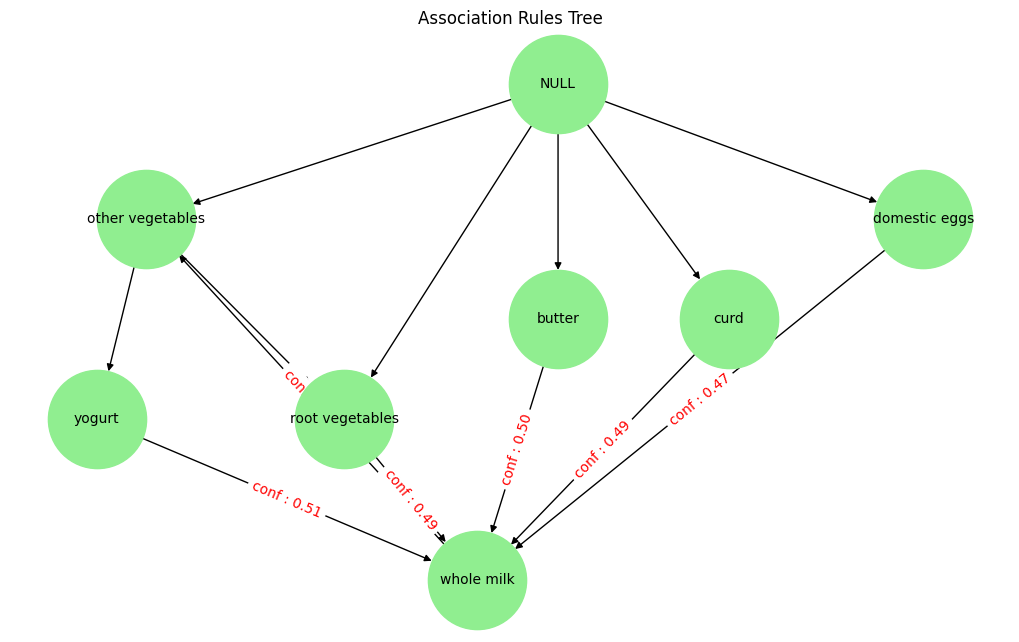

In [82]:
G = nx.DiGraph()

for _, row in rules.iterrows():
  lhs = tuple(row["antecedents"])
  rhs = tuple(row["consequents"])
  conf = row["confidence"]

  prev = "NULL"

  for item in lhs:
    if not G.has_edge(prev, item):
      G.add_edge(prev, item)
    prev = item

  for item in rhs:
    if not G.has_edge(prev, item):
      G.add_edge(prev, item, label = f"conf : {conf:.2f}")
    prev = item

pos = nx.nx_pydot.graphviz_layout(G, prog = "dot")
edge_labels = nx.get_edge_attributes(G, "label")

plt.figure(figsize = (10,6))
nx.draw(G, pos, with_labels = True, node_size = 5000, node_color = "lightgreen", font_size = 10, arrows = True)
nx.draw_networkx_edge_labels(G,pos, edge_labels = edge_labels, font_color = "red")
plt.title("Association Rules Tree")
plt.show()